# Praktikum Pengantar Pembelajaran Mesin


---
## Bab 7. Metode Evaluasi Klasifikasi

Nama: Hassan Nashrallah


NIM: 245150200111025


Kelas: F


## Membuat Fungsi-Fungsi Evaluasi yang Dibutuhkan

In [1]:
y_true = [0, 1, 2, 1, 2, 0, 1, 0, 2, 2] # Nilai sebenarnya
y_pred = [0, 1, 1, 1, 2, 0, 2, 0, 2, 1] # Prediksi
labels = [0, 1, 2] # Label kelas

In [2]:
import numpy as np

def confusion_matrix_multiclass(y_true, y_pred, labels):
  num_classes = len(labels)
  confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

  for true, pred in zip(y_true, y_pred):
    confusion_matrix[true][pred] += 1

  return confusion_matrix

def calculate_metrics(confusion_matrix):
  num_classes = confusion_matrix.shape[0]
  metrics = {}

  for i in range(num_classes):
    TP = confusion_matrix[i][i]
    FP = sum(confusion_matrix[:, i]) - TP
    FN = sum(confusion_matrix[i, :]) - TP
    TN = sum(confusion_matrix) - (TP + FP + FN)

    metrics[labels[i]] = {
      'TP': TP,
      'FP': FP,
      'FN': FN,
      'TN': TN
    }

  return metrics

confusion_matrix = confusion_matrix_multiclass(y_true, y_pred, labels)
metrics = calculate_metrics(confusion_matrix)

for label, metric in metrics.items():
    print(f"Class {label} - TP: {metric['TP']}, FP: {metric['FP']}, FN: {metric['FN']}, TN: {metric['TN']}")

Class 0 - TP: 3, FP: 0, FN: 0, TN: [0 1 0]
Class 1 - TP: 2, FP: 2, FN: 1, TN: [-2 -1 -2]
Class 2 - TP: 2, FP: 1, FN: 2, TN: [-2 -1 -2]


In [3]:
def hitung_precision_recall_f1_accuracy(y_true, y_pred, labels):
    cm = confusion_matrix_multiclass(y_true, y_pred, labels)
    metrics = calculate_metrics(cm)
    
    hasil = []
    for label, metric in metrics.items():
        precision = metric['TP'] / (metric['TP'] + metric['FP'])
        recall = metric['TP'] / (metric['TP'] + metric['FN'])
        f1_score = 2 * (precision * recall) / (precision + recall)
        accuracy_score = (metric['TP'] + metric['TN']) / (metric['TP'] + metric['FP'] + metric['FN'] + metric['TN'])
        
        hasil.append((f"Class {label} - Precision: {precision}, recall: {recall}, F1-Score: {f1_score}, accuracy: {accuracy_score}"))
    
    return hasil

display(hitung_precision_recall_f1_accuracy(y_true, y_pred, labels))

['Class 0 - Precision: 1.0, recall: 1.0, F1-Score: 1.0, accuracy: [1. 1. 1.]',
 'Class 1 - Precision: 0.5, recall: 0.6666666666666666, F1-Score: 0.5714285714285715, accuracy: [0.   0.25 0.  ]',
 'Class 2 - Precision: 0.6666666666666666, recall: 0.5, F1-Score: 0.5714285714285715, accuracy: [0.   0.25 0.  ]']

In [4]:
# Contoh data untuk roc-auc
y_true2 = [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]
y_pred2 = [0.1, 0.4, 0.35, 0.8, 0.7, 0.55, 0.65, 0.9, 0.3, 0.6]

In [5]:
def calculate_tpr_fpr(y_true, y_pred, threshold):
  tp = 0
  fp = 0
  fn = 0
  tn = 0

  for i in range(len(y_true)):
    if y_pred[i] >= threshold:
      if y_true[i] == 1:
        tp += 1
      else:
        fp += 1

    else:
      if y_true[i] == 1:
        fn += 1
      else:
        tn += 1

  tpr = tp / (tp + fn)
  fpr = fp / (fp + tn)

  return tpr, fpr

In [6]:
def calculate_roc_auc(y_true, y_pred):
  thresholds = sorted(set(y_pred), reverse=True)
  roc_points = []

  for threshold in thresholds:
    tpr, fpr = calculate_tpr_fpr(y_true, y_pred, threshold)
    roc_points.append((fpr, tpr))

  # Menghitung AUC menggunakan metode trapezoid
  auc = 0.0
  for i in range(1, len(roc_points)):
    x1, y1 = roc_points[i - 1]
    x2, y2 = roc_points[i]
    auc += (x2 - x1) * (y1 + y2) / 2.0

  return roc_points, auc

In [7]:
import matplotlib.pyplot as plt

def tampilkan_roc_curve(y_true, y_pred):
  roc_points, auc = calculate_roc_auc(y_true, y_pred)

  x, y = zip(*roc_points)
  plt.plot(x, y, marker='o')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')

  plt.grid(True)

  plt.show()

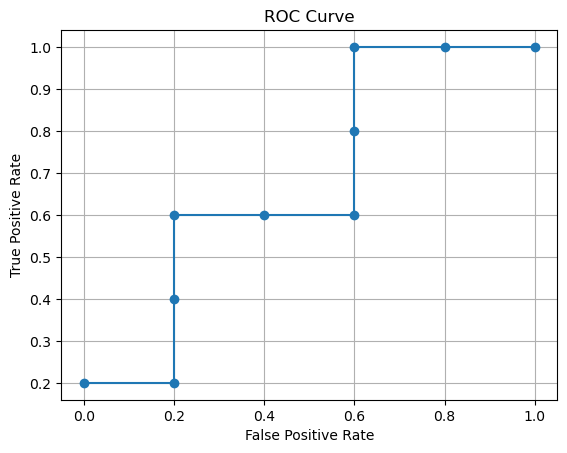

In [8]:
tampilkan_roc_curve(y_true2, y_pred2)

## 7.5. Tugas

1. Buatkan _method_ untuk menghitung F1-Score dan akurasi rata-rata!

In [9]:
def hitung_f1_score(y_true, y_pred, labels):
  cm = confusion_matrix_multiclass(y_true, y_pred, labels)
  metrics = calculate_metrics(cm)
  
  f1_scores = {}
  for label, metric in metrics.items():
      precision = metric['TP'] / (metric['TP'] + metric['FP'])
      recall = metric['TP'] / (metric['TP'] + metric['FN'])
      f1_score = 2 * (precision * recall) / (precision + recall)
      
      f1_scores[label] = f1_score
  
  return f1_scores

print("F1-Score:", hitung_f1_score(y_true, y_pred, labels))

def hitung_accuracy_rata(y_true, y_pred, labels):
  cm = confusion_matrix_multiclass(y_true, y_pred, labels)
  metrics = calculate_metrics(cm)
  
  akurasi = []
  for label, metric in metrics.items():
      skor_akurasi = (metric['TP'] + metric['TN']) / (metric['TP'] + metric['FP'] + metric['FN'] + metric['TN'])
      akurasi.append(skor_akurasi)
  
  return sum(akurasi) / len(akurasi)

print('Skor akurasi rata-rata:', hitung_accuracy_rata(y_true, y_pred, labels))

F1-Score: {0: np.float64(1.0), 1: np.float64(0.5714285714285715), 2: np.float64(0.5714285714285715)}
Skor akurasi rata-rata: [0.33333333 0.5        0.33333333]


2. Buat kode program untuk menghitung MCC dari percobaan subbab 7.4!

In [10]:
def hitung_mcc(y_true, y_pred, labels):
  cm = confusion_matrix_multiclass(y_true, y_pred, labels)
  total = cm.sum()
  
  mcc_scores = {}
  for i, label in enumerate(labels):
      TP = cm[i, i]
      FP = cm[:, i].sum() - TP
      FN = cm[i, :].sum() - TP
      TN = total - (TP + FP + FN)
      
      numerator = (TP * TN) - (FP * FN)
      denominator = ((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) ** 0.5
      
      mcc_score = (numerator / denominator) if denominator != 0 else 0.0
      mcc_scores[label] = float(mcc_score)
  
  return mcc_scores

print('Skor MCC:', hitung_mcc(y_true, y_pred, labels))

Skor MCC: {0: 1.0, 1: 0.3563483225498992, 2: 0.3563483225498992}


3. Gunakan semua matriks evaluasi yang ada di bab ini untuk menghitung kinerja SVM pada _dataset_ iris yang sudah dipraktikkan pada bab sebelumnya!

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

url = "https://gist.githubusercontent.com/Thanatoz-1/9e7fdfb8189f0cdf5d73a494e4a6392a/raw"
df = pd.read_csv(url)
X = df.drop(columns=['target'])
y = df['target']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_iris = svm_model.predict(X_test)
y_prob_iris = svm_model.predict_proba(X_test)
labels_iris = list(range(len(le.classes_)))

Evaluasi dengan confusion matrix: 
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
==================== Pemisah ====================
Evaluasi dengan beberapa skor untuk setiap kelasnya:


['Class 0 - Precision: 1.0, recall: 1.0, F1-Score: 1.0, accuracy: [1. 1. 1.]',
 'Class 1 - Precision: 1.0, recall: 0.9, F1-Score: 0.9473684210526316, accuracy: [0.9        0.88888889 0.90909091]',
 'Class 2 - Precision: 0.9090909090909091, recall: 1.0, F1-Score: 0.9523809523809523, accuracy: [0.9        0.88888889 0.90909091]']

==================== Pemisah ====================
Evaluasi dengan nilai dari ROC: [(0.5, 0.1), (0.5, 1.0), (1.0, 1.0)]
AUC: 0.5



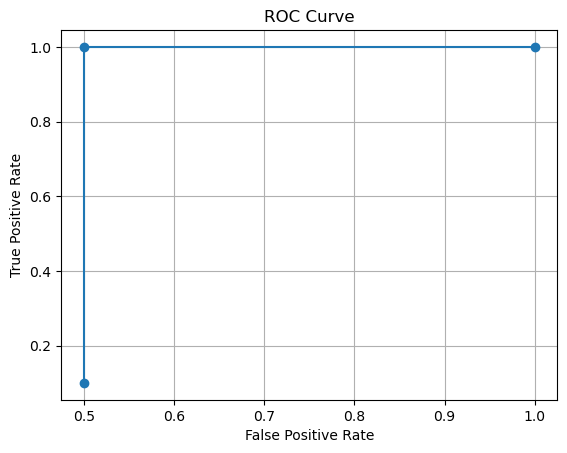

==================== Pemisah ====================
Evaluasi dengan skor MCC:
{0: 1.0, 1: 0.9258200997725514, 2: 0.929320377284585}


In [24]:
# Evaluasi dengan metode Confusion Matrix
print('Evaluasi dengan confusion matrix: ')
print(confusion_matrix_multiclass(y_test, y_pred_iris, labels_iris)) # panggil fungsi untuk menampilkan confusion matrix

print('==================== Pemisah ====================')

# Evaluasi dengan metode Precision, Recall, F1, dan Accuracy
print('Evaluasi dengan beberapa skor untuk setiap kelasnya:')
display(hitung_precision_recall_f1_accuracy(y_test, y_pred_iris, labels_iris)) # panggil fungsi untuk menapmilkan evaluasi dengan precision, recall, f1, dan akurasi

print('==================== Pemisah ====================')

# Evaluasi dengan menghitung ROC dan AUC
roc_auc = calculate_roc_auc(y_test, y_pred_iris) # dapatkan perhitung poin ROC dan AUC
print(f'Evaluasi dengan nilai dari ROC: {roc_auc[0]}\nAUC: {roc_auc[1]}\n')
tampilkan_roc_curve(y_test, y_pred_iris) # tampilkan grafik ROC curve

print('==================== Pemisah ====================')

# Evaluasi dengan menghitung MCC
print(f'Evaluasi dengan skor MCC:')
print(hitung_mcc(y_test, y_pred_iris, labels_iris)) # panggil fungsi untuk menghitung evaluasi dengan MCC

## 7.6. Kesimpulan

Kesimpulan apa yang kamu dapatkan selama praktikum Modul 7 ini, menjawab dari pertanyaan-pertanyaan di bawah ini:
1. Apakah tujuan percobaan telah tercapai?
2. Apa hubungan antara hasil percobaan dan dasar teori?
3. Faktor-faktor apa saja yang memengaruhi hasil percobaan, termasuk kemungkinan kesalahan yang terjadi?

1. Tujuan percobaan dapat dikatakan telah tercapai karena pada percobaan ini kita berhasil melakukan implementasi dan menguji berbagai metode evaluasi pada model klasifikasi, seperti confusion matrix, accuracy, precision, recall, F1-score, ROC curve, AUC, serta MCC. Selain itu, kita juga berhasil menerapkan evaluasi tersebut pada model SVM menggunakan dataset Iris sehingga dapat diketahui performa model klasifikasi secara lebih menyeluruh.

2. Hasil percobaan menunjukkan hubungan yang sesuai dengan dasar teori evaluasi klasifikasi. Confusion matrix digunakan sebagai dasar untuk menghitung berbagai metrik evaluasi seperti precision, recall, dan F1-score. Nilai accuracy yang tinggi menunjukkan bahwa model mampu melakukan prediksi dengan baik terhadap sebagian besar data uji. Selain itu, ROC curve dan AUC digunakan untuk melihat kemampuan model dalam membedakan kelas berdasarkan nilai threshold tertentu. Hal ini sesuai dengan teori bahwa evaluasi model tidak cukup hanya dengan menggunakan accuracy. Diperlukan metrik tambahan, seperti ROC-AUC, untuk memperoleh gambaran performa model yang lebih lengkap.

3. Hasil percobaan dipengaruhi oleh beberapa faktor, seperti distribusi data, pembagian data latih dan data uji, pemilihan parameter model SVM, serta preprocessing data. Kemungkinan kesalahan yang dapat terjadi dapat berupa kesalahan implementasi rumus evaluasi, kesalahan dalam perhitungan confusion matrix, penggunaan threshold yang kurang tepat pada ROC-AUC, maupun kesalahan interpretasi hasil evaluasi.